# Meta 2 ECAC - Testing Feature Selection Methods

In [1]:
# Importation of all Frameworks and Tools needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy import stats
from scipy.stats import skew, kurtosis, iqr
from scipy.signal import welch
from scipy.fft import rfft, rfftfreq
from scipy.interpolate import interp1d


Importing Feature Dataset obtained in meta1 and altering it so it contains participant id 

In [2]:
# Importing the dataset and filtering activities
df = pd.read_csv('feature_set.csv')
df_filtered = df[df["Activity"].isin(range(1, 8))].copy()
print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"Unique activities after filtering: {df_filtered['Activity'].unique()}")



Filtered dataset shape: (1405, 179)
Unique activities after filtering: [1 2 3 4 5 6 7]


Repeating the same feature extraction principals from first meta 

In [3]:
# ==========================================
# 1. HELPER FUNCTIONS (Dependencies)
# ==========================================

def dominant_frequency(signal, fs):
    n = len(signal)
    if n == 0: return 0
    yf = np.abs(rfft(signal))
    xf = rfftfreq(n, d=1/fs)
    dominant_idx = np.argmax(yf[1:]) + 1 
    if dominant_idx >= len(xf): return 0
    return xf[dominant_idx]

def spectral_entropy(signal, fs):
    freqs, psd = welch(signal, fs=fs)
    psd_sum = np.sum(psd)
    if psd_sum == 0: return 0
    psd_norm = psd / psd_sum
    entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    return entropy

def zero_crossing_rate(signal):
    return np.sum(np.diff(np.sign(signal)) != 0) / len(signal)

def mean_crossing_rate(signal):
    mean_val = np.mean(signal)
    centered = signal - mean_val
    return np.sum(np.diff(np.sign(centered)) != 0) / len(signal)

def extract_statistical_features(signal, fs):
    signal = signal.astype(float)
    return [
        np.mean(signal), np.median(signal), np.std(signal), np.var(signal),
        np.sqrt(np.mean(signal**2)), np.mean(np.diff(signal)),
        skew(signal), kurtosis(signal), iqr(signal),
        zero_crossing_rate(signal), mean_crossing_rate(signal),
        spectral_entropy(signal, fs),
    ]

def extract_correlations(window):
    features = []
    axes = window.shape[1]
    for i in range(axes):
        for j in range(i + 1, axes):
            if np.std(window[:, i]) == 0 or np.std(window[:, j]) == 0:
                features.append(0)
            else:
                features.append(np.corrcoef(window[:, i], window[:, j])[0, 1])
    return features

def extract_feature_vector(window, fs):
    features = []
    # Statistical features only
    for i in range(window.shape[1]):
        features.extend(extract_statistical_features(window[:, i], fs))
    features.extend(extract_correlations(window))
    return np.array(features)

def sliding_windows(data, labels, window_sec=5, overlap=0.5, fs=50):
    window_size = int(window_sec * fs)
    if window_size < 1: window_size = 1
    step_size = int(window_size * (1 - overlap))
    if step_size < 1: step_size = 1
    
    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        window = data[start:end]
        label_segment = labels[start:end]
        if np.all(label_segment == label_segment[0]):
            yield window, label_segment[0]

# ==========================================
# 2. MISSING FUNCTIONS (The Fix)
# ==========================================

def generate_features_from_df(df):
    """
    Takes a dataframe, estimates sampling rate, and extracts features.
    """
    print("Extracting features from subset...")
    
    # Estimate FS
    diffs = df["Timestamp"].diff()
    avg_diff = diffs[diffs > 0].median()
    
    if avg_diff > 1: 
        fs = 1000.0 / avg_diff
    elif avg_diff > 0:
        fs = 1.0 / avg_diff
    else:
        fs = 50.0
        
    print(f"  - Sampling Rate: {fs:.2f} Hz")
    
    data_cols = ["Acc_x","Acc_y","Acc_z","Gyro_x","Gyro_y","Gyro_z","Mag_x","Mag_y","Mag_z"]
    data = df[data_cols].values
    labels = df["Activity"].values
    
    X_list = []
    y_list = []
    
    count = 0
    for window, label in sliding_windows(data, labels, fs=fs):
        feat = extract_feature_vector(window, fs)
        X_list.append(feat)
        y_list.append(label)
        count += 1
        
    print(f"  - Extracted {count} windows.")
    
    if count == 0:
        return pd.DataFrame()

    X = np.array(X_list)
    y = np.array(y_list)
    
    feat_cols = [f"Feature_{i}" for i in range(X.shape[1])]
    df_feats = pd.DataFrame(X, columns=feat_cols)
    df_feats["Activity"] = y
    
    return df_feats.dropna()

def generate_synthetic_samples(X, y, target_activity, n_new_samples=3):
    print(f"Generating {n_new_samples} synthetic samples for Activity {target_activity}...")
    current_count = np.sum(y == target_activity)
    
    if current_count < 2:
        print("Error: Not enough samples to use SMOTE.")
        return None, None, None
        
    strategy = {target_activity: current_count + n_new_samples}
    k = min(current_count - 1, 5)
    smote = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=42)
    
    X_res, y_res = smote.fit_resample(X, y)
    
    if not isinstance(X_res, pd.DataFrame):
         X_res = pd.DataFrame(X_res, columns=X.columns)

    n_synthetic = len(X_res) - len(X)
    X_synthetic = X_res.iloc[-n_synthetic:]
    y_synthetic = y_res.iloc[-n_synthetic:]
    
    return X_res, y_res, X_synthetic

Importing the Raw dataset (so we can have access to each participant activity)

In [4]:

# ==========================================
# 1. UPDATED Data Loading (Loads EVERYTHING)
# ==========================================

def load_full_raw_dataset():
    """
    Loads raw data for ALL participants (0-14) and ALL devices (1-5).
    Adds a 'Participant' column to distinguish them.
    """
    df_list = []
    
    # Iterate through all participants (0 to 14 based on your metadata)
    for part in range(15):
        print(f"Loading data for Participant {part}...")
        for device in range(1, 6): # Devices 1 to 5
            url = f"https://raw.githubusercontent.com/spl-icsforth/FORTH_TRACE_DATASET/master/part{part}/part{part}dev{device}.csv"
            try:
                # Columns based on FORTH-TRACE documentation
                cols = ["DeviceId", "Acc_x", "Acc_y", "Acc_z", 
                        "Gyro_x", "Gyro_y", "Gyro_z", 
                        "Mag_x", "Mag_y", "Mag_z", 
                        "Timestamp", "Activity"]
                
                temp_df = pd.read_csv(url, header=None, names=cols)
                
                # CRITICAL: Add Participant ID so we can filter later
                temp_df["Participant"] = part 
                
                df_list.append(temp_df)
                # Optional: Print less to keep output clean, or print every file
                # print(f"  - Loaded Device {device}")
            except Exception as e:
                print(f"  - Error loading Part {part} Device {device}: {e}")
                
    # Combine everything into one massive DataFrame
    print("Concatenating all datasets...")
    full_df = pd.concat(df_list, axis=0, ignore_index=True)
    print(f"DONE. Total Raw Shape: {full_df.shape}")
    return full_df



Checking whether the dataset is balanced or not 

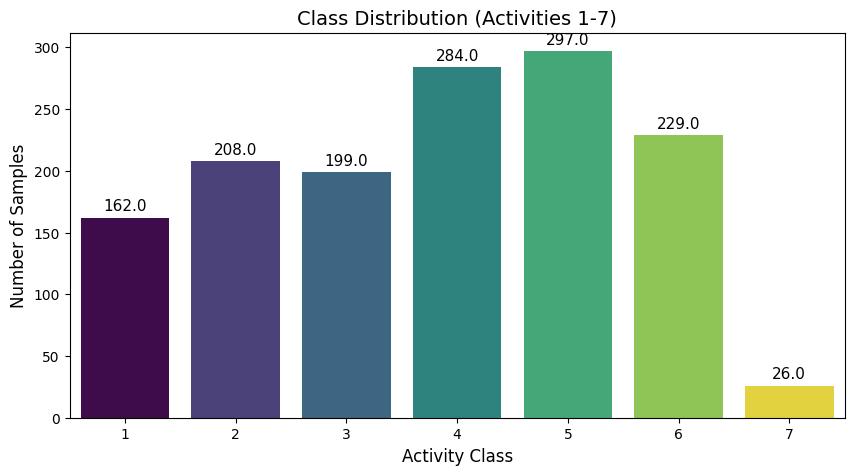


--- Exact Counts per Activity ---
Activity
1    162
2    208
3    199
4    284
5    297
6    229
7     26
Name: count, dtype: int64

Imbalance Ratio (Max/Min): 11.42


In [5]:
# Extract Labels (y)
y = df_filtered['Activity'].values
# Visualize Class Distribution
plt.figure(figsize=(10, 5))
# Use seaborn to plot count of each activity
ax = sns.countplot(x=y, hue=y,  palette="viridis" , legend=False)
plt.title('Class Distribution (Activities 1-7)', fontsize=14)
plt.xlabel('Activity Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()
# Numerical Summary
print("\n--- Exact Counts per Activity ---")
print(df_filtered['Activity'].value_counts().sort_index())

# Check for Imbalance
counts = df_filtered['Activity'].value_counts()
min_count = counts.min()
max_count = counts.max()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

1.2 Defining a SMOTE Function

In [6]:
def generate_synthetic_samples(X, y, target_activity, n_new_samples=3):
    print(f"Generating {n_new_samples} synthetic samples for Activity {target_activity}...")
    current_count = np.sum(y == target_activity)
    
    if current_count < 2:
        print("Error: Not enough samples to use SMOTE.")
        return None, None, None
        
    strategy = {target_activity: current_count + n_new_samples}
    k = min(current_count - 1, 5)
    smote = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=42)
    
    X_res, y_res = smote.fit_resample(X, y)
    
    if not isinstance(X_res, pd.DataFrame):X_res = pd.DataFrame(X_res, columns=X.columns)

    n_synthetic = len(X_res) - len(X)
    X_synthetic = X_res.iloc[-n_synthetic:]
    y_synthetic = y_res.iloc[-n_synthetic:]
    
    return X_res, y_res, X_synthetic

1.3 Applying the SMOTE function

Loading data for Participant 0...
Loading data for Participant 1...
Loading data for Participant 2...
Loading data for Participant 3...
Loading data for Participant 4...
Loading data for Participant 5...
Loading data for Participant 6...
Loading data for Participant 7...
Loading data for Participant 8...
Loading data for Participant 9...
Loading data for Participant 10...
Loading data for Participant 11...
Loading data for Participant 12...
Loading data for Participant 13...
Loading data for Participant 14...
Concatenating all datasets...
DONE. Total Raw Shape: (3930873, 13)

--- Processing Participant 3 ---
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 1898 windows.
Generating 3 synthetic samples for Activity 4...


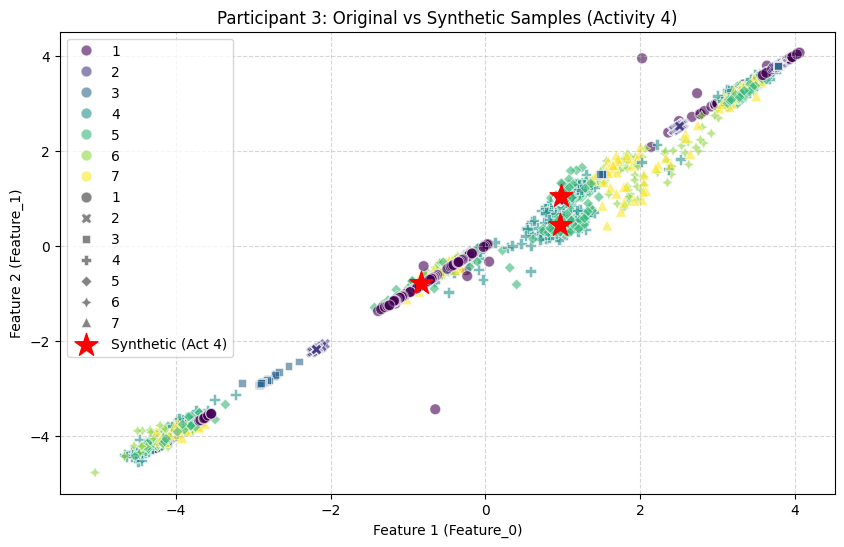

In [7]:
# A. Load the ENTIRE raw dataset (Once)
# -------------------------------------
if 'df_all_raw' not in locals(): # check if already loaded to save time in notebooks
    df_all_raw = load_full_raw_dataset()
else:
    print("Dataset already loaded. Skipping download.")

# B. Filter for Participant 3 ONLY
# --------------------------------
print("\n--- Processing Participant 3 ---")
df_part3_raw = df_all_raw[df_all_raw["Participant"] == 3].copy()

if df_part3_raw.empty:
    print("Error: No data found for Participant 3.")
else:
    # C. Generate Features for Part 3
    df_features_p3 = generate_features_from_df(df_part3_raw)

    # D. Filter for Meta 2 Requirements (Activities 1-7)
    df_features_p3 = df_features_p3[df_features_p3["Activity"] <= 7]

    # E. Prepare for SMOTE (Target: Activity 4)
    target_act = 4
    X = df_features_p3.drop(columns=["Activity"])
    y = df_features_p3["Activity"]

    # F. Run SMOTE Logic
    X_resampled, y_resampled, X_syn = generate_synthetic_samples(X, y, target_act, n_new_samples=3)

    # G. Visualization
    if X_syn is not None:
        # Use only first two features for 2D plot
        feat_x = X.columns[0]
        feat_y = X.columns[1]
        
        plt.figure(figsize=(10, 6))
        
        # 1. Plot original points (colored by activity)
        sns.scatterplot(data=df_features_p3, x=feat_x, y=feat_y, hue="Activity", style="Activity", palette="viridis", alpha=0.6,s=60)
        # 2. Highlight synthetic points (Red Stars)
        plt.scatter(X_syn[feat_x], X_syn[feat_y], color='red', marker='*', s=300, label='Synthetic (Act 4)',zorder=10)
        plt.title(f"Participant 3: Original vs Synthetic Samples (Activity {target_act})")
        plt.xlabel(f"Feature 1 ({feat_x})")
        plt.ylabel(f"Feature 2 ({feat_y})")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

2.1 Extracting features using Embedding

In [8]:
# ==========================================
# 1. EXACT FUNCTIONS FROM embeddings_extractor.py
# ==========================================

def load_model():
    ''' Loads the model from the github repo and obtains just the feature encoder. '''
    
    print("Loading Harnet5 model...")
    repo = 'OxWearables/ssl-wearables'
    # class_num não interessa para extrair features; mas o hub pede este arg
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    model.eval()

    # Passo crucial: ficar só com a parte auto-supervisionada
    feature_encoder = model.feature_extractor
    
    # Note: The original script forces CPU. We will allow moving to GPU later if needed.
    feature_encoder.to("cpu")
    feature_encoder.eval()

    return feature_encoder

def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target

def acc_segmentation(data):
    ''' Estract ACC segments and their activities '''

    TIMESTAMP_COL = 10
    MIN_SEGMENT_SIZE = 20
    fs_in_hz = 51.5 # Unused inside, but kept for strict adherence
    win_size = 5000
    start_time = data[0,TIMESTAMP_COL]
    end_time = start_time + win_size

    activities = []
    segments = []

    while end_time < data[-1,TIMESTAMP_COL]:
        mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

        if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

            acc_xyz = data[mask,1:4]
            activity = data[mask, -1][0]
            
            activities.append(activity)
            segments.append( acc_xyz )
      
        start_time = end_time - win_size/2
        end_time = start_time + win_size
  
    return segments, activities

# ==========================================
# 2. UPDATED GENERATOR (Using the functions above)
# ==========================================

def generate_embeddings_dataset(df_raw):
    # 1. Setup Model
    feature_encoder = load_model()
    
    # Optimization: Move to GPU if available (overriding the CPU default in load_model)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    feature_encoder.to(device)
    print(f"Model moved to {device} for processing.")
    
    # 2. Process Group-by-Group
    grouped = df_raw.groupby(["Participant", "DeviceId"])
    all_embeddings_list = []
    
    print(f"Processing {len(grouped)} segments...")
    
    for (part_id, dev_id), group_df in grouped:
        
        # --- A. PREPARE DATA FOR acc_segmentation ---
        # 1. Estimate Sampling Rate
        diffs = group_df["Timestamp"].diff()
        avg_diff = diffs[diffs > 0].median()
        
        # 2. Handle Units (Seconds vs Milliseconds)
        # acc_segmentation uses win_size = 5000 (ms). If data is in seconds, we must scale it.
        # We create a copy of the values to avoid modifying the original dataframe
        
        # Slice to exclude 'Participant' so 'Activity' is at index -1
        # Expected columns by acc_segmentation: [DeviceId, Acc_x, Acc_y, Acc_z, ... Timestamp, Activity]
        # Timestamp is at index 10. Acc is 1:4. Activity is -1.
        
        # Check current columns to ensure we pass the right slice
        # Ideally: DeviceId(0), Acc_x(1), Acc_y(2), Acc_z(3), Gyro... Timestamp(10), Activity(11)
        # If 'Participant' is col 12, we perform .iloc[:, :12]
        
        # Robust selection assuming standard FORTH dataset structure
        # We need the first 12 columns: 0..11
        data_np = group_df.iloc[:, :12].values.copy()
        
        if avg_diff < 1.0: 
            fs = 1.0 / avg_diff
            # Convert Seconds -> Milliseconds for segmentation logic
            data_np[:, 10] = data_np[:, 10] * 1000.0
        else:
            fs = 1000.0 / avg_diff
            # Already in ms, no change needed
        
        # --- B. SEGMENTATION ---
        # Call the exact function provided
        segments_raw, seg_labels = acc_segmentation(data_np)
        
        if not segments_raw:
            continue
            
        # --- C. RESAMPLING ---
        # Call the exact function provided for each segment
        segments_resampled = []
        for seg in segments_raw:
            # resample_to_30hz_5s returns (data, fs_target) -> we take [0]
            res_seg = resample_to_30hz_5s(seg, fs)[0]
            segments_resampled.append(res_seg)
            
        # --- D. EMBEDDING GENERATION ---
        batch_np = np.array(segments_resampled) 
        batch_np = np.transpose(batch_np, (0, 2, 1)) # (B, 3, 150)
        
        batch_size = 64
        with torch.no_grad():
            for i in range(0, len(batch_np), batch_size):
                chunk_np = batch_np[i : i+batch_size]
                chunk_tensor = torch.from_numpy(chunk_np).float().to(device)
                
                embeddings = feature_encoder(chunk_tensor)
                emb_np = embeddings.cpu().numpy()
                
                # Fix 3D shape if necessary
                if emb_np.ndim > 2:
                    emb_np = emb_np.reshape(emb_np.shape[0], -1)
                
                batch_res = pd.DataFrame(emb_np)
                batch_res["Activity"] = seg_labels[i : i+batch_size]
                batch_res["Participant"] = part_id
                
                all_embeddings_list.append(batch_res)

    # 3. Finalize
    if not all_embeddings_list:
        return pd.DataFrame()
        
    final_df = pd.concat(all_embeddings_list, ignore_index=True)
    
    # Rename columns
    feat_cols = [c for c in final_df.columns if isinstance(c, int)]
    rename_map = {c: f"Emb_{c}" for c in feat_cols}
    final_df = final_df.rename(columns=rename_map)
    
    return final_df

# ==========================================
# 3. EXECUTION
# ==========================================

if 'df_all_raw' in locals():
    print("\nGenerating Embeddings (Using exact provided functions)...")
    # Filter 1-7
    df_raw_filtered = df_all_raw[df_all_raw["Activity"] <= 7].copy()
    
    # Run
    EMBEDDINGS_DATASET = generate_embeddings_dataset(df_raw_filtered)
    
    print(f"\nDONE. Embeddings Dataset Shape: {EMBEDDINGS_DATASET.shape}")
    print(EMBEDDINGS_DATASET.head())
else:
    print("Error: df_all_raw not loaded.")


Generating Embeddings (Using exact provided functions)...
Loading Harnet5 model...


Using cache found in C:\Users\ramya/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
Model moved to cpu for processing.
Processing 75 segments...

DONE. Embeddings Dataset Shape: (29720, 514)
   Emb_0  Emb_1  Emb_2  Emb_3     Emb_4     Emb_5  Emb_6     Emb_7  Emb_8  \
0    0.0    0.0    0.0    0.0  0.028251  0.052633    0.0  0.043271    0.0   
1    0.0    0.0    0.0    0.0  0.024366  0.047597    0.0  0.052120    0.0   
2    0.0    0.0    0.0    0.0  0.026458  0.053930    0.0  0.049916    0.0   
3    0.0    0.0    0.0    0.0  0.027667  0.050848    0.0  0.043369    0.0   
4    0.0    0.0    0.0    0.0  0.028083  0.044541    0.0  0.047659    0.0   

      Emb_9  ...   Emb_504  Emb_505  Emb_506   Emb_507   Emb_508   Emb_509  \
0  0.043261  ...  0.005634      0.0      0.0  0.009069  0.086691  0.039299   
1  0.038358  ...  0.011343      0.0      0.0  0.009913  0.087089  0.038609   
2  0.041910  ...  0.006098      0.0      0.0  0.010750  0.083309  0.042045   
3  0.043349  ...  0.004550      0.0      0.0  0.009165  0.086541  0.037584   
4  0.039425  ...  0.0

Generating a complementary dataset to the meta 1 in order to keep the Participant ID


In [9]:
# ==========================================
# REGENERATE FEATURES DATASET (With IDs)
# ==========================================

def create_features_dataset_with_ids(df_raw):
    print("Regenerating Features Dataset to include Participant IDs...")
    
    # We process each participant separately to assign the correct ID
    # Grouping by Participant AND Device ensures we don't mix signals
    grouped = df_raw.groupby(["Participant", "DeviceId"])
    
    all_features_list = []
    
    for (part_id, dev_id), group_df in grouped:
        # Use your existing function to extract features for this small chunk
        # (suppressing prints to avoid spamming)
        try:
            # We assume generate_features_from_df is already defined in your notebook
            feats_df = generate_features_from_df(group_df)
            
            if not feats_df.empty:
                # CRITICAL STEP: Tag these rows with the Participant ID
                feats_df["Participant"] = part_id
                all_features_list.append(feats_df)
                
        except Exception as e:
            continue

    if not all_features_list:
        return pd.DataFrame()
    
    # Combine everything
    final_df = pd.concat(all_features_list, ignore_index=True)
    return final_df

# ==========================================
# EXECUTION
# ==========================================

if 'df_all_raw' in locals():
    # 1. Filter Raw Data (Activities 1-7 only, as per instructions)
    df_raw_filtered = df_all_raw[df_all_raw["Activity"] <= 7].copy()
    
    # 2. Create the Dataset
    FEATURES_DATASET = create_features_dataset_with_ids(df_raw_filtered)
    
    print("\n--- SUCCESS ---")
    print(f"FEATURES DATASET Shape: {FEATURES_DATASET.shape}")
    print(f"Columns: {list(FEATURES_DATASET.columns[:5])} ... 'Participant'")
    
    # Now you have both datasets ready for splitting!
else:
    print("Error: 'df_all_raw' is not loaded. Please run the Data Loading cell first.")

Regenerating Features Dataset to include Participant IDs...
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 373 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 371 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


...

  - Extracted 375 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 376 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 375 windows.

--- SUCCESS ---
FEATURES DATASET Shape: (29387, 146)
Columns: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'] ... 'Participant'


3.1 Splitting the dataset 

In [10]:


def perform_within_subject_split_stratified(df):
    """
    Splits 60-20-20 using 'Participant + Activity' as the stratification key.
    This ensures every subject AND every activity is balanced across sets
    without needing a slow loop.
    """
    # 1. Create an Interaction Column (Participant_Activity) to stratify by
    # This forces the split to respect both the User and the Activity ratios
    stratify_col = df['Participant'].astype(str) + "_" + df['Activity'].astype(str)
    
    # 2. First Split: Train (60%) vs Temp (40%)
    # We use the interaction column for stratification
    train_df, temp_df = train_test_split(
        df,
        test_size=0.4,
        random_state=42,
        stratify=stratify_col
    )
    
    # Update stratification key for the second split (since indices changed)
    stratify_col_temp = temp_df['Participant'].astype(str) + "_" + temp_df['Activity'].astype(str)
    
    # 3. Second Split: Val (20%) vs Test (20%)
    # Splitting the remaining 40% in half = 20% total each
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=42,
        stratify=stratify_col_temp
    )
    
    return train_df, val_df, test_df

# ==========================================
# EXECUTION
# ==========================================

print("--- 3.1 Within-Subject Split (Interaction Method) ---")

# 1. Features Dataset
if 'FEATURES_DATASET' in locals():
    print("\nSplitting FEATURES DATASET...")
    try:
        X_train_f, X_val_f, X_test_f = perform_within_subject_split_stratified(FEATURES_DATASET)
        print(f"  Train: {len(X_train_f)} | Val: {len(X_val_f)} | Test: {len(X_test_f)}")
    except ValueError as e:
        print(f"  ! Error: Some Participant-Activity combinations have too few samples to split (needs at least 2).")
        print("  ! Switching back to simple per-participant loop method is recommended if this fails.")

# 2. Embeddings Dataset
if 'EMBEDDINGS_DATASET' in locals():
    print("\nSplitting EMBEDDINGS DATASET...")
    try:
        X_train_e, X_val_e, X_test_e = perform_within_subject_split_stratified(EMBEDDINGS_DATASET)
        print(f"  Train: {len(X_train_e)} | Val: {len(X_val_e)} | Test: {len(X_test_e)}")
    except ValueError:
        print(f"  ! Error during stratification (classes too small).")

--- 3.1 Within-Subject Split (Interaction Method) ---

Splitting FEATURES DATASET...
  Train: 17632 | Val: 5877 | Test: 5878

Splitting EMBEDDINGS DATASET...
  Train: 17832 | Val: 5944 | Test: 5944


In [11]:
# ==========================================
# 3.2 BETWEEN-SUBJECT SPLIT (9-3-3)
# ==========================================

def perform_between_subject_split(df):
    """
    Splits the dataset by Participant ID:
    - Train: 9 Subjects (0-8)
    - Val:   3 Subjects (9-11)
    - Test:  3 Subjects (12-14)
    """
    # Define the groups
    train_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    val_ids   = [9, 10, 11]
    test_ids  = [12, 13, 14]
    
    # Filter
    train_df = df[df["Participant"].isin(train_ids)].copy()
    val_df   = df[df["Participant"].isin(val_ids)].copy()
    test_df  = df[df["Participant"].isin(test_ids)].copy()
    
    return train_df, val_df, test_df

print("--- 3.2 Performing Between-Subject Splits (9 Train / 3 Val / 3 Test) ---")

# 1. Features Dataset
if 'FEATURES_DATASET' in locals():
    print("\nSplitting FEATURES DATASET...")
    X_train_f_bt, X_val_f_bt, X_test_f_bt = perform_between_subject_split(FEATURES_DATASET)
    
    print(f"  Train: {len(X_train_f_bt)} samples (Participants 0-8)")
    print(f"  Val:   {len(X_val_f_bt)} samples (Participants 9-11)")
    print(f"  Test:  {len(X_test_f_bt)} samples (Participants 12-14)")
else:
    print("Warning: FEATURES_DATASET not found.")

# 2. Embeddings Dataset
if 'EMBEDDINGS_DATASET' in locals():
    print("\nSplitting EMBEDDINGS DATASET...")
    X_train_e_bt, X_val_e_bt, X_test_e_bt = perform_between_subject_split(EMBEDDINGS_DATASET)
    
    print(f"  Train: {len(X_train_e_bt)} samples (Participants 0-8)")
    print(f"  Val:   {len(X_val_e_bt)} samples (Participants 9-11)")
    print(f"  Test:  {len(X_test_e_bt)} samples (Participants 12-14)")
else:
    print("Warning: EMBEDDINGS_DATASET not found.")

--- 3.2 Performing Between-Subject Splits (9 Train / 3 Val / 3 Test) ---

Splitting FEATURES DATASET...
  Train: 18373 samples (Participants 0-8)
  Val:   5405 samples (Participants 9-11)
  Test:  5609 samples (Participants 12-14)

Splitting EMBEDDINGS DATASET...
  Train: 17875 samples (Participants 0-8)
  Val:   5897 samples (Participants 9-11)
  Test:  5948 samples (Participants 12-14)


Normalization of The train and test data of both Embedding and Featureset datasets before we proceed to the next steps

In [12]:

# ==========================================
# NORMALIZATION FUNCTION
# ==========================================

def normalize_datasets(train_df, val_df, test_df, dataset_name):
    """
    Separates Features (X) and Labels (y), then applies StandardScaler.
    Constraint: Fit on TRAIN, Transform on VAL and TEST.
    """
    print(f"\nProcessing Normalization for: {dataset_name}")
    
    # 1. Define Columns to Drop (Metadata)
    # We remove Activity (Target), Participant (ID), and any stratification helper cols
    drop_cols = ["Activity", "Participant", "Participant_Activity"]
    
    # 2. Extract X (Features) and y (Labels)
    # --------------------------------------
    X_train = train_df.drop(columns=drop_cols, errors='ignore').values
    y_train = train_df["Activity"].values
    
    X_val = val_df.drop(columns=drop_cols, errors='ignore').values
    y_val = val_df["Activity"].values
    
    X_test = test_df.drop(columns=drop_cols, errors='ignore').values
    y_test = test_df["Activity"].values
    
    # 3. Normalize
    # ------------
    scaler = StandardScaler()
    
    # CRITICAL: Fit ONLY on Training Data
    scaler.fit(X_train)
    
    # Transform all sets using the Training statistics
    X_train_norm = scaler.transform(X_train)
    X_val_norm = scaler.transform(X_val)
    X_test_norm = scaler.transform(X_test)
    
    print(f"  > Done. Feature range (Train): {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")
    
    return (X_train_norm, y_train), (X_val_norm, y_val), (X_test_norm, y_test)

# ==========================================
# EXECUTION
# ==========================================

# Dictionary to store Scenario A (Normalized Data)
# Structure: normalized_data['Features']['Train'] -> (X, y)
normalized_data = {
    'Features': {},
    'Embeddings': {}
}

# 1. Normalize FEATURES Dataset (Using Between-Subject Split from Step 3.2)
if 'X_train_f_bt' in locals():
    train_set, val_set, test_set = normalize_datasets(
        X_train_f_bt, X_val_f_bt, X_test_f_bt, "Features (Between-Subject)"
    )
    normalized_data['Features']['Train'] = train_set
    normalized_data['Features']['Val']   = val_set
    normalized_data['Features']['Test']  = test_set

# 2. Normalize EMBEDDINGS Dataset (Using Between-Subject Split from Step 3.2)
if 'X_train_e_bt' in locals():
    train_set, val_set, test_set = normalize_datasets(
        X_train_e_bt, X_val_e_bt, X_test_e_bt, "Embeddings (Between-Subject)"
    )
    normalized_data['Embeddings']['Train'] = train_set
    normalized_data['Embeddings']['Val']   = val_set
    normalized_data['Embeddings']['Test']  = test_set

print("\n--- NORMALIZATION COMPLETE ---")
print("You now have normalized data ready for Scenario B (PCA) and C (ReliefF).")


Processing Normalization for: Features (Between-Subject)
  > Done. Feature range (Train): -19.19 to 39.35

Processing Normalization for: Embeddings (Between-Subject)
  > Done. Feature range (Train): -1.93 to 133.69

--- NORMALIZATION COMPLETE ---
You now have normalized data ready for Scenario B (PCA) and C (ReliefF).


Proceeding to do 3.4

In [13]:
# Try importing ReliefF (requires 'skrebate' package)
try:
    from skrebate import ReliefF
    HAS_RELIEFF = True
except ImportError:
    HAS_RELIEFF = False
    print("Warning: 'skrebate' library not found. Using SelectKBest (ANOVA) instead of ReliefF.")

# ==========================================
# 3.4 TRANSFORMATION PIPELINE
# ==========================================

def apply_transformations(train_df, val_df, test_df, dataset_name):
    """
    Inputs: Raw Train/Val/Test DataFrames (with 'Activity' and 'Participant')
    Outputs: A dictionary containing 3 Scenarios:
            ['All', 'PCA', 'ReliefF'] -> {'Train': (X,y), 'Val': (X,y), 'Test': (X,y)}
    """
    print(f"\n[{dataset_name}] Starting Transformation Pipeline...")
    
    scenarios = {}
    
    # Helper to separate X and y
    drop_cols = ["Activity", "Participant", "Participant_Activity"]
    def split_xy(df):
        X = df.drop(columns=drop_cols, errors='ignore').values
        y = df["Activity"].values
        return X, y

    X_train, y_train = split_xy(train_df)
    X_val, y_val     = split_xy(val_df)
    X_test, y_test   = split_xy(test_df)

    # ---------------------------------------------------------
    # SCENARIO A: ALL FEATURES (Normalized)
    # ---------------------------------------------------------
    print("  > [A] Normalizing data...")
    scaler = StandardScaler()
    
    # CRITICAL: Fit ONLY on Training Data
    X_train_norm = scaler.fit_transform(X_train)
    X_val_norm   = scaler.transform(X_val)
    X_test_norm  = scaler.transform(X_test)
    
    scenarios['All'] = {
        'Train': (X_train_norm, y_train),
        'Val':   (X_val_norm, y_val),
        'Test':  (X_test_norm, y_test)
    }

    # ---------------------------------------------------------
    # SCENARIO B: PCA (90% Variance)
    # ---------------------------------------------------------
    print("  > [B] Applying PCA (90% Variance)...")
    # CRITICAL: Fit PCA ONLY on Training Data (Normalized)
    pca = PCA(n_components=0.90)
    
    X_train_pca = pca.fit_transform(X_train_norm)
    X_val_pca   = pca.transform(X_val_norm)
    X_test_pca  = pca.transform(X_test_norm)
    
    n_comps = X_train_pca.shape[1]
    print(f"    - Reduced dimensions from {X_train.shape[1]} to {n_comps}")
    
    scenarios['PCA'] = {
        'Train': (X_train_pca, y_train),
        'Val':   (X_val_pca, y_val),
        'Test':  (X_test_pca, y_test)
    }

    # ---------------------------------------------------------
    # SCENARIO C: FEATURE SELECTION (ReliefF - Top 15)
    # ---------------------------------------------------------
    print("  > [C] Applying Feature Selection (Top 15)...")
    TOP_K = 15
    
    # Select Feature Selection Algorithm
    if HAS_RELIEFF:
        # Optimization: Fit ReliefF on a subset if training set is huge
        MAX_SAMPLES = 2000
        if len(X_train_norm) > MAX_SAMPLES:
            idx = np.random.choice(len(X_train_norm), MAX_SAMPLES, replace=False)
            X_train_fit = X_train_norm[idx]
            y_train_fit = y_train[idx]
        else:
            X_train_fit = X_train_norm
            y_train_fit = y_train
            
        fs_model = ReliefF(n_features_to_select=TOP_K, n_neighbors=100, n_jobs=-1)
        fs_model.fit(X_train_fit, y_train_fit)
        
        # Transform the full datasets
        X_train_sel = fs_model.transform(X_train_norm)
        X_val_sel   = fs_model.transform(X_val_norm)
        X_test_sel  = fs_model.transform(X_test_norm)
        
    else:
        # Fallback to SelectKBest (ANOVA)
        fs_model = SelectKBest(f_classif, k=TOP_K)
        fs_model.fit(X_train_norm, y_train)
        
        X_train_sel = fs_model.transform(X_train_norm)
        X_val_sel   = fs_model.transform(X_val_norm)
        X_test_sel  = fs_model.transform(X_test_norm)

    scenarios['Selected'] = {
        'Train': (X_train_sel, y_train),
        'Val':   (X_val_sel, y_val),
        'Test':  (X_test_sel, y_test)
    }
    
    return scenarios

# ==========================================
# EXECUTION
# ==========================================

# Dictionary to store ALL prepared data
# Access: final_data['Features_Between']['PCA']['Train']
final_data = {}

# 1. Process FEATURES Dataset (Between-Subject Split)
if 'X_train_f_bt' in locals():
    final_data['Features_Between'] = apply_transformations(
        X_train_f_bt, X_val_f_bt, X_test_f_bt, "Features (Between-Subject)"
    )

# 2. Process EMBEDDINGS Dataset (Between-Subject Split)
if 'X_train_e_bt' in locals():
    final_data['Embeddings_Between'] = apply_transformations(
        X_train_e_bt, X_val_e_bt, X_test_e_bt, "Embeddings (Between-Subject)"
    )

# 3. Process FEATURES Dataset (Within-Subject Split) - Optional
if 'X_train_f' in locals():
    final_data['Features_Within'] = apply_transformations(
        X_train_f, X_val_f, X_test_f, "Features (Within-Subject)"
    )
    
# 4. Process EMBEDDINGS Dataset (Within-Subject Split) - Optional
if 'X_train_e' in locals():
    final_data['Embeddings_Within'] = apply_transformations(
        X_train_e, X_val_e, X_test_e, "Embeddings (Within-Subject)"
    )

print("\n--- 3.4 PIPELINE COMPLETE ---")
print("Data is transformed and ready for Section 5 (Model Evaluation).")


[Features (Between-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 144 to 64
  > [C] Applying Feature Selection (Top 15)...

[Embeddings (Between-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 512 to 11
  > [C] Applying Feature Selection (Top 15)...

[Features (Within-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 144 to 65
  > [C] Applying Feature Selection (Top 15)...

[Embeddings (Within-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 512 to 11
  > [C] Applying Feature Selection (Top 15)...

--- 3.4 PIPELINE COMPLETE ---
Data is transformed and ready for Section 5 (Model Evaluation).
